## Imports

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    dtw, 
    format_stats, 
    mean_center, 
    show_source
)

## Functions

In [2]:
show_source(dtw)

In [3]:
show_source(mean_center)

In [4]:
show_source(format_stats)

In [5]:
def pairwise_precedence(event_matches):
    event_positions = {
        ev.item(): np.flatnonzero(event_matches == ev) 
        for ev in np.unique(event_matches)
    }
    precedence = {}
    for a, b in itertools.combinations(event_positions.keys(), 2):
        a_positions = event_positions[a]
        b_positions = event_positions[b]
        a_prec_count = 0
        for i in a_positions:
            for j in b_positions:
                if i < j:
                    a_prec_count += 1
        precedence[(a, b)] = a_prec_count / (len(a_positions) * len(b_positions))
    return precedence

In [6]:
def order_similarity(precedence_a, precedence_b, shared_events):
    if len(shared_events) < 2:
        raise ValueError('No common event pairs recalled')
    shared_pairs = list(itertools.combinations(sorted(shared_events), 2))
    total = 0
    for a_b in shared_pairs:
        total += abs(precedence_a[a_b] - precedence_b[a_b])
    return 1 - total / len(shared_pairs)

## Load data

In [7]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [8]:
ep_events_centered = atlep1.events - atlep1.events.mean(axis=0)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

## Is delayed recall more similar to own immediate recall than to episode?

In [9]:
warp_dists_imm = []
warp_dists_episode = []

for imm_events, del_events in zip(imm_events_centered, del_events_centered):
    dist_imm = dtw(del_events, imm_events)[0]
    dist_ep = dtw(del_events, ep_events_centered)[0]
    warp_dists_imm.append(dist_imm)
    warp_dists_episode.append(dist_ep)
    
T, p = wilcoxon(warp_dists_episode, warp_dists_imm, alternative='greater')
T, p = T.item(), p.item()
print(f'mean immediate-alignment cost: {np.mean(warp_dists_imm):.4f}')
print(f'mean episode-alignment cost: {np.mean(warp_dists_episode):.4f}')
print(f'{T=}, {p=:.4e}')

mean immediate-alignment cost: 0.5321
mean episode-alignment cost: 0.6539
T=1430.0, p=1.2637e-10


In [10]:
df = pd.DataFrame(columns=('Comparison', 'participant', 'Warp distance'))
df['Comparison'] = np.repeat(['delayed-->immediate', 'delayed-->episode'], len(participants))
df['participant'] = np.tile(np.arange(1, len(participants) + 1), 2)
df['Warp distance'] = np.concatenate((warp_dists_imm, warp_dists_episode))

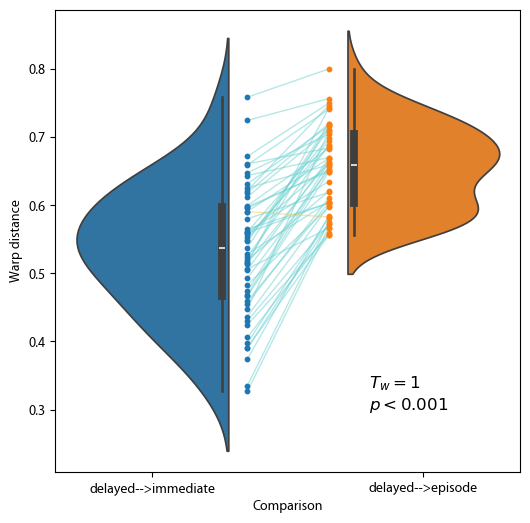

In [11]:
fig, ax = plt.subplots(1, figsize=(6, 6))
ax = sns.violinplot(df, x='Comparison', y='Warp distance', hue='Comparison', split=True, gap=0.3)
inner_boxplot_xshift = 0.01
for line in ax.lines:
    xdata = line.get_xdata()
    center = np.mean(xdata)
    direction = -1 if center < 0.5 else 1  # left vs right violin
    line.set_xdata([x + direction * inner_boxplot_xshift for x in xdata])


scatter_point_size = 10
scatter_x_offset = 0.35
connection_linewidth = 1
connection_alpha = 0.5
decrease_color = '#f9c74f'
increase_color = '#6cd0d0'
no_change_color = 'grey'

imm_scatter_xcoords = np.zeros(len(warp_dists_imm)) + scatter_x_offset
ep_scatter_xcoords = np.ones(len(warp_dists_episode)) - scatter_x_offset

ax.scatter(imm_scatter_xcoords, 
           warp_dists_imm, 
           s=scatter_point_size, 
           zorder=2)
ax.scatter(ep_scatter_xcoords, 
           warp_dists_episode, 
           s=scatter_point_size, 
           zorder=2)
ax.plot([imm_scatter_xcoords, ep_scatter_xcoords], 
        [warp_dists_imm, warp_dists_episode], 
        c=no_change_color, 
        alpha=connection_alpha, 
        lw=connection_linewidth, 
        zorder=1)

for connection_line in ax.get_lines()[-len(participants):]:
    y_imm, y_ep = connection_line.get_ydata()
    if y_imm > y_ep:
        connection_line.set_color(decrease_color)
    elif y_imm < y_ep:
        connection_line.set_color(increase_color)

T, p = wilcoxon(warp_dists_imm, warp_dists_episode)
stat_text =  format_stats(T, p, 'T_w', n_decimals_stat=0)
ax.text(0.8, 0.3, stat_text, fontsize='large')
plt.show()

## Is delayed recall more similar to own immediate recall than to *others'* immediate recalls?

In [12]:
warp_dists_self = np.array(warp_dists_imm[:])
warp_dists_others = np.empty((len(participants), len(participants) - 1), dtype=float)

for i in range(len(participants)):
    del_events = del_events_centered[i]
    dists_ix = 0
    for j in range(len(participants)):
        if j != i:
            warp_dist_other = dtw(del_events, imm_events_centered[j])[0]
            warp_dists_others[i, dists_ix] = warp_dist_other
            dists_ix += 1
            
pct_ranks = np.empty_like(warp_dists_self)
for i, own in enumerate(warp_dists_self):
    others = warp_dists_others[i]
    pct_ranks[i] = ((own < others).sum() + (own == others).sum() * 0.5) / len(others)
    
print(wilcoxon(pct_ranks, 0.5, alternative='greater'))

WilcoxonResult(statistic=np.float64(1431.0), pvalue=np.float64(2.182214068738512e-11))


## Is delayed recall order more similar to own immediate recall order than to others' immediate recall orders?

In [13]:
imm_precs = []
del_precs = []

for p in participants:
    imm_event_matches = p.event_matches['atlep1']
    del_event_matches = p.event_matches['delayed']
    imm_precs.append(pairwise_precedence(imm_event_matches))
    del_precs.append(pairwise_precedence(del_event_matches))
    
order_sims_self = []
order_sims_others = np.empty((len(participants), len(participants) - 1), dtype=float)

for i, del_prec in enumerate(del_precs):
    p = participants[i]
    del_event_matches = p.event_matches['delayed']
    imm_event_matches = p.event_matches['atlep1']
    shared_events = set(del_event_matches) & set(imm_event_matches)
    sim_self = order_similarity(del_prec, imm_precs[i], shared_events)
    order_sims_self.append(sim_self)
    
    sims_ix = 0
    for j, other_imm_prec in enumerate(imm_precs):
        if j != i:
            other_imm_event_matches = participants[j].event_matches['atlep1']
            shared_events = set(del_event_matches) & set(other_imm_event_matches)
            sim_other = order_similarity(del_prec, imm_precs[j], shared_events)
            order_sims_others[i, sims_ix] = sim_other
            sims_ix += 1
            
pct_ranks = np.empty_like(order_sims_self)
for i, own in enumerate(order_sims_self):
    others = order_sims_others[i]
    pct_ranks[i] = ((own > others).sum() + (own == others).sum() * 0.5) / len(others)
    
print(wilcoxon(pct_ranks, 0.5, alternative='greater'))

WilcoxonResult(statistic=np.float64(1076.5), pvalue=np.float64(0.0006955909257345347))
